**LOAD**

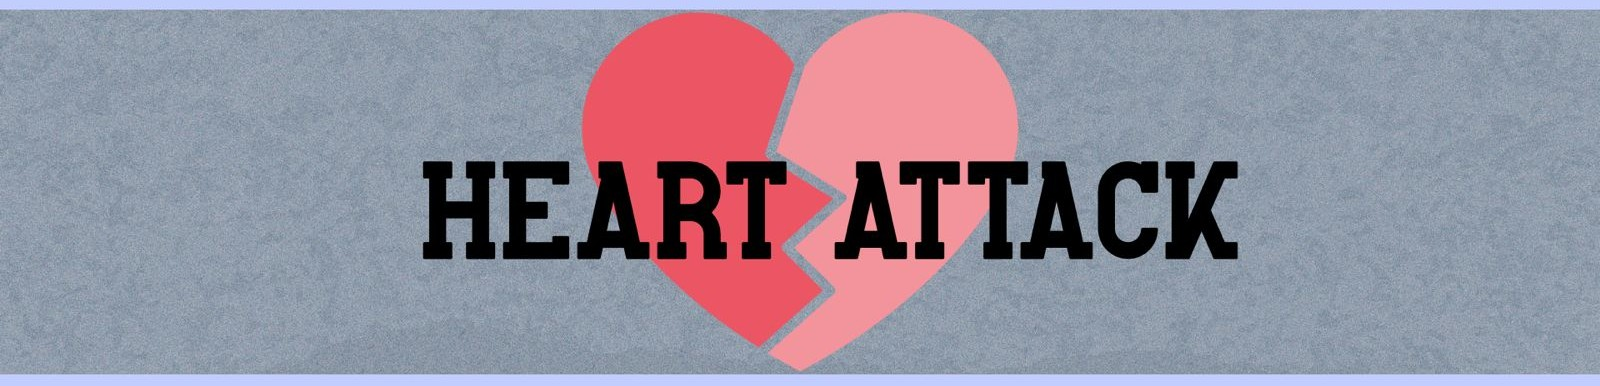

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

###### 1. CARGA DE DATOS
Se carga el dataset especificando el delimitador ';' ya que no es un CSV estándar separado por comas.

In [ ]:
df = pd.read_csv("/content/healthcare-dataset-stroke-data.csv", sep= ";")

**INSPECT**

In [ ]:
df.shape

(5110, 11)

In [ ]:
df.index

RangeIndex(start=0, stop=5110, step=1)

In [ ]:
df.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             5110 non-null   object 
 1   age                5110 non-null   float64
 2   hypertension       5110 non-null   int64  
 3   heart_disease      5110 non-null   int64  
 4   ever_married       5110 non-null   object 
 5   work_type          5110 non-null   object 
 6   Residence_type     5110 non-null   object 
 7   avg_glucose_level  5110 non-null   float64
 8   bmi                4909 non-null   float64
 9   smoking_status     5110 non-null   object 
 10  stroke             5110 non-null   int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 439.3+ KB


In [ ]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


#### Análisis Exploratorio Univariado
Antes de transformar los datos, revisamos la distribución general de nuestros pacientes, sus condiciones de salud y estilo de vida.

In [ ]:
print("DEMOGRAFÍA Y ESTILO DE VIDA")
print("Estado Civil:\n", df['ever_married'].value_counts().to_string())
print("\nTipo de Residencia:\n", df['Residence_type'].value_counts().to_string())
print("\nGénero:\n", df['gender'].value_counts().to_string())
print(f"\nPacientes Jóvenes (15 a 20 años): {df['age'].between(15,20).sum()}")

print("\n\nCONDICIONES DE SALUD")
print("Estado de fumador:\n", df['smoking_status'].value_counts().to_string())
print("\nEnfermedad Cardíaca (0=No, 1=Sí):\n", df['heart_disease'].value_counts().to_string())
print("\nHipertensión (0=No, 1=Sí):\n", df['hypertension'].value_counts().to_string())

print("\n\nÍNDICE DE MASA CORPORAL (BMI)")
print(f"Peso normal (18.5 - 24.9): {df['bmi'].between(18.5, 24.9).sum()} pacientes")
print(f"Sobrepeso (25.0 - 29.9): {df['bmi'].between(25, 29.9).sum()} pacientes")

DEMOGRAFÍA Y ESTILO DE VIDA
Estado Civil:
 ever_married
Yes    3353
No     1757

Tipo de Residencia:
 Residence_type
Urban    2596
Rural    2514

Género:
 gender
Female    2994
Male      2115
Other        1

Pacientes Jóvenes (15 a 20 años): 326


CONDICIONES DE SALUD
Estado de fumador:
 smoking_status
never smoked       1892
Unknown            1544
formerly smoked     885
smokes              789

Enfermedad Cardíaca (0=No, 1=Sí):
 heart_disease
0    4834
1     276

Hipertensión (0=No, 1=Sí):
 hypertension
0    4612
1     498


ÍNDICE DE MASA CORPORAL (BMI)
Peso normal (18.5 - 24.9): 1243 pacientes
Sobrepeso (25.0 - 29.9): 1409 pacientes


### **CLEAN**
**Comparación de Estrategias: Data Cleaning y Feature Engineering**.

En esta sección vamos a comparar qué sucede con las métricas del dataset si eliminamos los valores nulos (NaN) de la columna `bmi` frente a si los imputamos (rellenamos) usando la mediana.
Este paso es crucial porque la variable objetivo `stroke` está fuertemente desbalanceada.

In [ ]:
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
ever_married,0
work_type,0
Residence_type,0
avg_glucose_level,0
bmi,201
smoking_status,0


In [ ]:
df_drop = df.dropna().copy()

In [ ]:
df_impute = df.copy()
mediana_bmi = df_impute['bmi'].median()
df_impute['bmi'] = df_impute['bmi'].fillna(mediana_bmi)

In [ ]:
df_drop.shape

(5110, 11)

In [ ]:
df_impute.shape

(5110, 11)

In [ ]:
print("--- IMPACTO EN LA VARIABLE OBJETIVO ---")
print(f"Total casos de infarto en dataset original: {df['stroke'].sum()}")
print(f"Total casos de infarto tras DROPNA: {df_drop['stroke'].sum()} (Perdimos {df['stroke'].sum() - df_drop['stroke'].sum()} casos)")
print(f"Total casos de infarto tras IMPUTAR: {df_impute['stroke'].sum()} (Mantenemos todos los casos)")

--- IMPACTO EN LA VARIABLE OBJETIVO ---
Total casos de infarto en dataset original: 249
Total casos de infarto tras DROPNA: 209 (Perdimos 40 casos)
Total casos de infarto tras IMPUTAR: 249 (Mantenemos todos los casos)


#### Transformación de Variables Categóricas (Encoding)
Para poder graficar la correlación numérica, debemos convertir las variables de texto (`gender`, `ever_married`, `work_type`, `Residence_type`, `smoking_status`) en formato numérico binario mediante el método One-Hot Encoding. Lo aplicaremos a ambos casos.

In [ ]:
columnas_categoricas = ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

df_drop_encoded = pd.get_dummies(df_drop, columns=columnas_categoricas, drop_first=True)
df_impute_encoded = pd.get_dummies(df_impute, columns=columnas_categoricas, drop_first=True)

Transformación exitosa. Listo para calcular correlaciones.


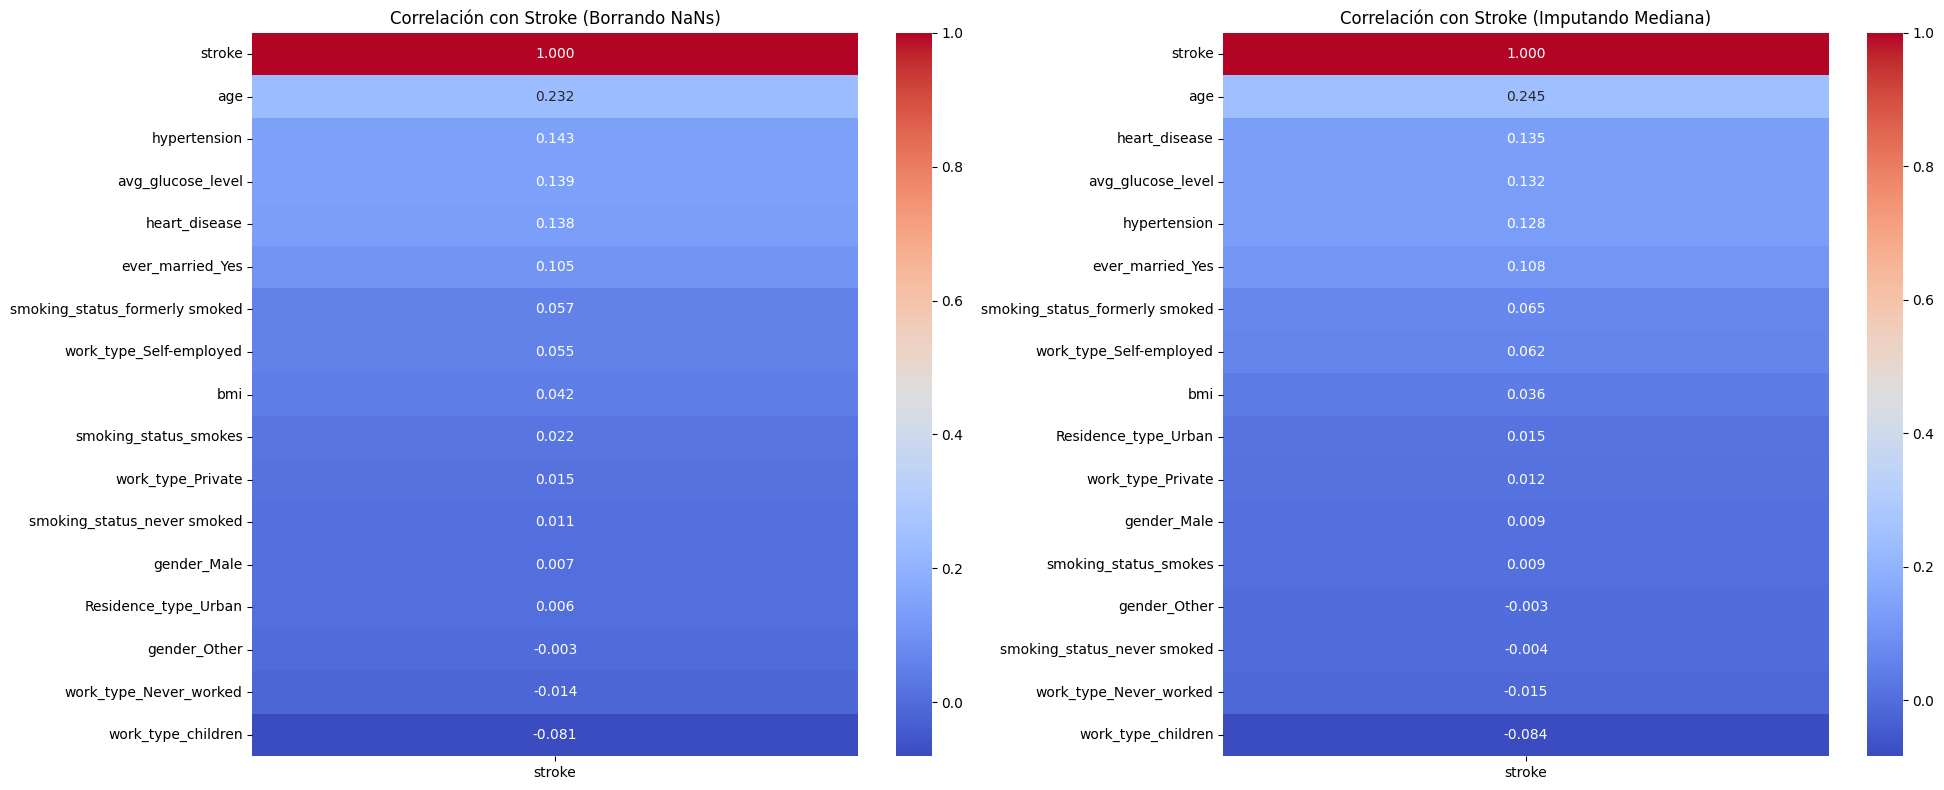

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Heatmap Caso 1 (Drop)
sns.heatmap(df_drop_encoded.corr()[['stroke']].sort_values(by='stroke', ascending=False), annot=True, cmap='coolwarm', fmt=".3f", ax=axes[0])
axes[0].set_title('Correlación con Stroke (Borrando NaNs)')

# Heatmap Caso 2 (Impute)
sns.heatmap(df_impute_encoded.corr()[['stroke']].sort_values(by='stroke', ascending=False), annot=True, cmap='coolwarm', fmt=".3f", ax=axes[1])
axes[1].set_title('Correlación con Stroke (Imputando Mediana)')

plt.tight_layout()
plt.show()

#### Análisis Bivariado: Cruce de variables de Estilo de Vida vs Infarto
Analisis de cómo se distribuyen los infartos dependiendo de si la persona fuma o no.

Caso 1 (Drop)


stroke,0,1
smoking_status,,
Unknown,98.04%,1.96%
formerly smoked,93.19%,6.81%
never smoked,95.46%,4.54%
smokes,94.71%,5.29%



Caso 2 (Impute)


stroke,0,1
smoking_status,,
Unknown,96.96%,3.04%
formerly smoked,92.09%,7.91%
never smoked,95.24%,4.76%
smokes,94.68%,5.32%


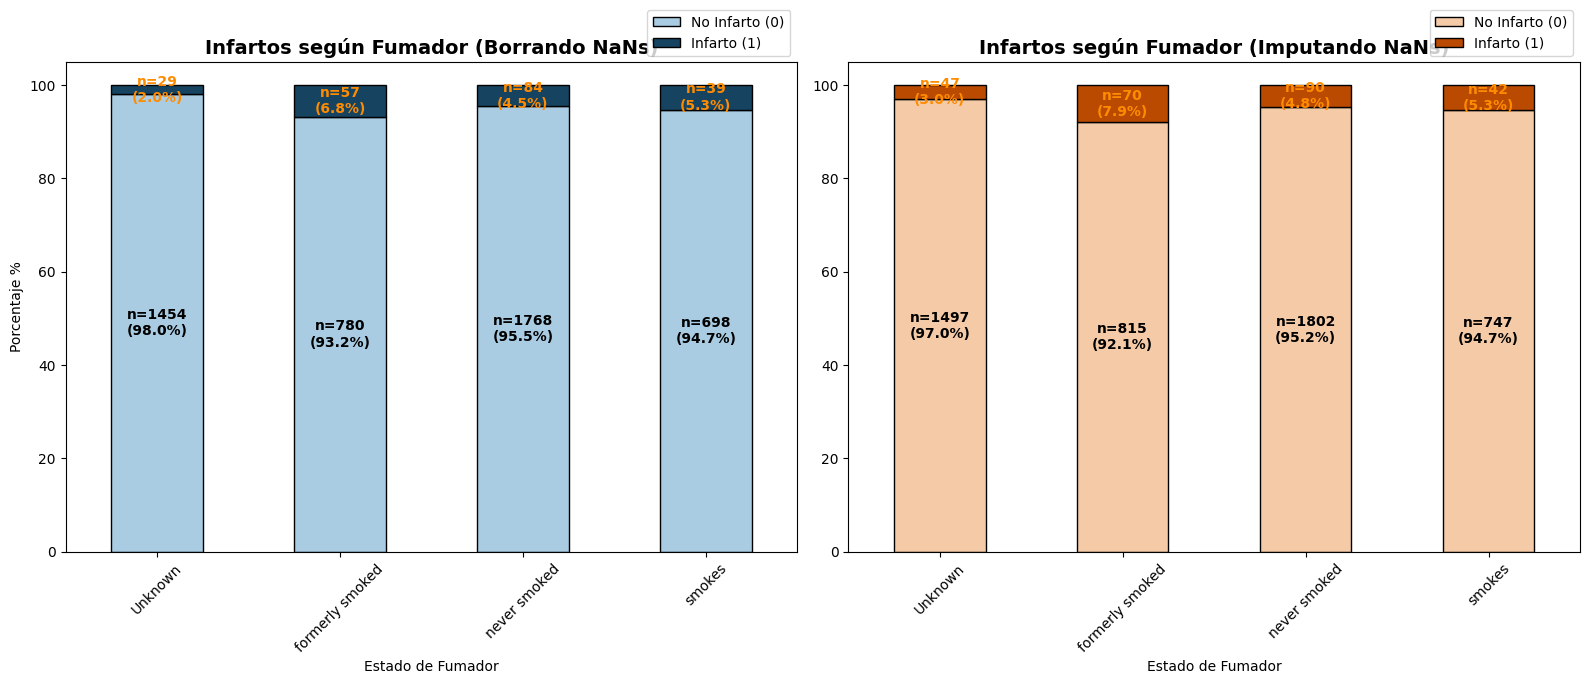

In [ ]:
ct_drop_pct = pd.crosstab(df_drop['smoking_status'], df_drop['stroke'], normalize='index') * 100
ct_impute_pct = pd.crosstab(df_impute['smoking_status'], df_impute['stroke'], normalize='index') * 100

ct_drop_count = pd.crosstab(df_drop['smoking_status'], df_drop['stroke'])
ct_impute_count = pd.crosstab(df_impute['smoking_status'], df_impute['stroke'])

print("Caso 1 (Drop)")
display(ct_drop_pct.style.background_gradient(cmap='Blues').format("{:.2f}%"))

print("\nCaso 2 (Impute)")
display(ct_impute_pct.style.background_gradient(cmap='Oranges').format("{:.2f}%"))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

colores_drop = ['#A9CCE3', '#154360']
colores_impute = ['#F5CBA7', '#BA4A00']

# Caso 1 (Drop)
ct_drop_pct.plot(kind='bar', stacked=True, ax=axes[0], color=colores_drop, edgecolor='black')
axes[0].set_title('Infartos según Fumador (Borrando NaNs)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Porcentaje %')
axes[0].set_xlabel('Estado de Fumador')
axes[0].legend(['No Infarto (0)', 'Infarto (1)'], loc='upper right', bbox_to_anchor=(1, 1.12))
axes[0].tick_params(axis='x', rotation=45)

# Caso 2 (Impute)
ct_impute_pct.plot(kind='bar', stacked=True, ax=axes[1], color=colores_impute, edgecolor='black')
axes[1].set_title('Infartos según Fumador (Imputando NaNs)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Estado de Fumador')
axes[1].legend(['No Infarto (0)', 'Infarto (1)'], loc='upper right', bbox_to_anchor=(1, 1.12))
axes[1].tick_params(axis='x', rotation=45)

def agregar_etiquetas(ax, df_pct, df_count):
    for i, (index, row) in enumerate(df_pct.iterrows()):
        acumulado = 0
        for col in df_pct.columns:
            porcentaje = row[col]
            conteo = df_count.loc[index, col]

            if porcentaje > 0:
                y_pos = acumulado + (porcentaje / 2)
                color_texto = 'darkorange' if col == 1 else 'black'
                ax.text(i, y_pos, f"n={conteo}\n({porcentaje:.1f}%)",
                        ha='center', va='center', color=color_texto, fontweight='bold', fontsize=10)

            acumulado += porcentaje

agregar_etiquetas(axes[0], ct_drop_pct, ct_drop_count)
agregar_etiquetas(axes[1], ct_impute_pct, ct_impute_count)

plt.tight_layout()
plt.show()


#### Comparación de Outliers
El Índice de Masa Corporal (BMI) es una variable que presenta múltiples valores atípicos. El borrar vs imputar los valores nulos afecta la cantidad y distribución de outliers, utilizando diagramas de caja (Boxplots) y el método del Rango Intercuartílico (IQR).

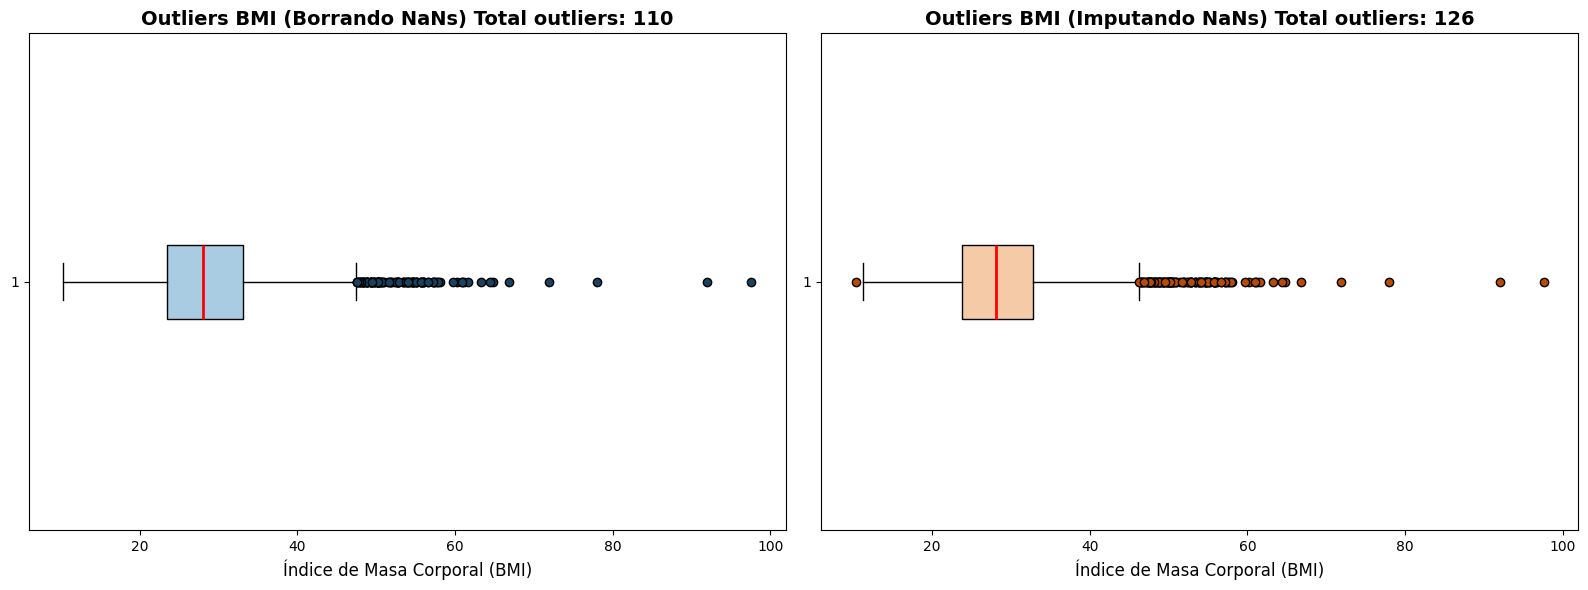

In [ ]:
def contar_outliers(df, columna):
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[columna] < Q1 - 1.5 * IQR) | (df[columna] > Q3 + 1.5 * IQR)]
    return len(outliers)

outliers_drop = contar_outliers(df_drop, 'bmi')
outliers_impute = contar_outliers(df_impute, 'bmi')
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Caso 1 (Drop)
axes[0].boxplot(df_drop['bmi'], patch_artist=True, vert=False, boxprops=dict(facecolor='#A9CCE3', color='black'), medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#154360', markeredgecolor='black', markersize=6, linestyle='none'))
axes[0].set_title(f'Outliers BMI (Borrando NaNs) Total outliers: {outliers_drop}', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Índice de Masa Corporal (BMI)', fontsize=12)

# Caso 2 (Impute)
axes[1].boxplot(df_impute['bmi'], patch_artist=True, vert=False, boxprops=dict(facecolor='#F5CBA7', color='black'), medianprops=dict(color='red', linewidth=2),
                flierprops=dict(marker='o', markerfacecolor='#BA4A00', markeredgecolor='black', markersize=6, linestyle='none'))
axes[1].set_title(f'Outliers BMI (Imputando NaNs) Total outliers: {outliers_impute}', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Índice de Masa Corporal (BMI)', fontsize=12)

plt.tight_layout()
plt.show()

 #### Comparación: Distribución del Tipo de Trabajo (Pie Chart)
A continuación, analizaremos si la eliminación de los valores nulos afectó la distribución demográfica de nuestro dataset, específicamente en la variable `work_type` (Tipo de trabajo).

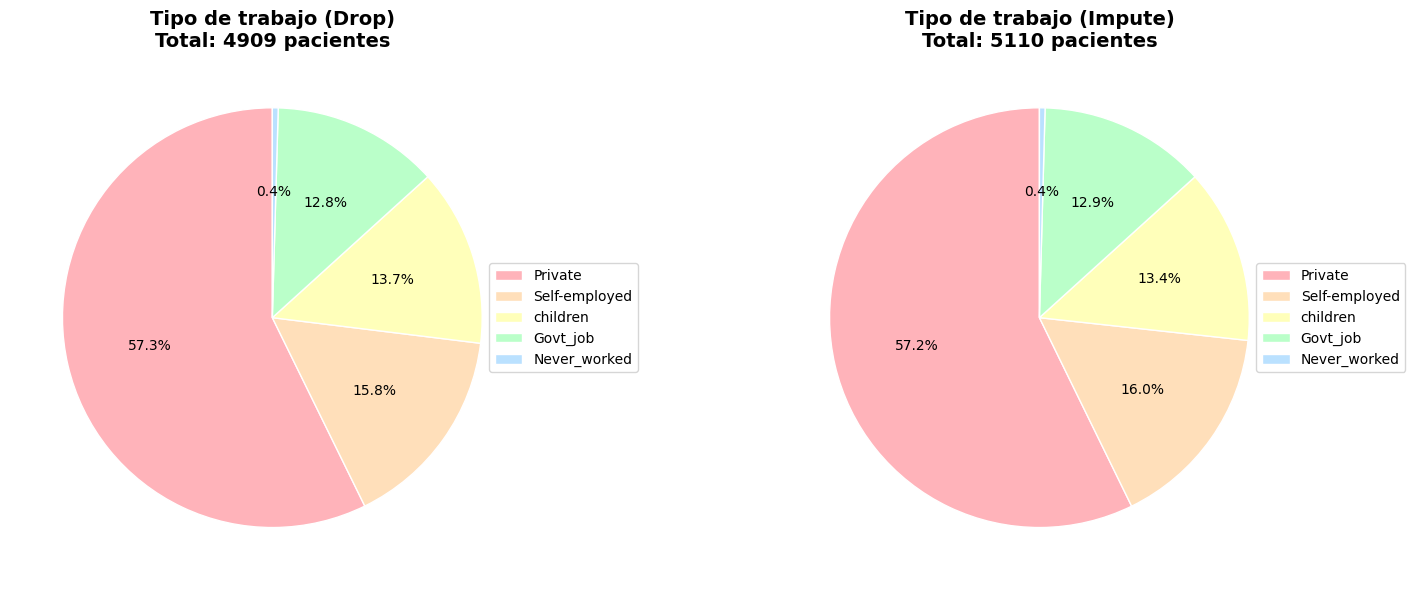

In [ ]:
counts_drop = df_drop['work_type'].value_counts()
counts_impute = df_impute['work_type'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colores = ['#FFB3BA','#FFDFBA','#FFFFBA','#BAFFC9','#BAE1FF']

# Caso 1 (Drop)
axes[0].pie(counts_drop, labels=None, autopct='%1.1f%%', startangle=90, colors=colores, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[0].set_title(f'Tipo de trabajo (Drop)\nTotal: {len(df_drop)} pacientes', fontsize=14, fontweight='bold')
axes[0].legend(counts_drop.index, loc='center left', bbox_to_anchor=(0.9, 0.5))

# Caso 2 (Impute)
axes[1].pie(counts_impute, labels=None, autopct='%1.1f%%', startangle=90, colors=colores, wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[1].set_title(f'Tipo de trabajo (Impute)\nTotal: {len(df_impute)} pacientes', fontsize=14, fontweight='bold')
axes[1].legend(counts_impute.index, loc='center left', bbox_to_anchor=(0.9, 0.5))

plt.tight_layout()
plt.show()